In [ ]:
# PHASE 0: Setup - Import Libraries & Ignore Warnings

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models & utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, log_loss, classification_report
)

# Ignore warnings (cleaner output in Colab)
import warnings
warnings.filterwarnings('ignore')

# Visualization style
sns.set(style="whitegrid")

print("Libraries successfully loaded!")

Libraries successfully loaded!


In [ ]:
# Load the dataset (ensure the file is uploaded in Colab)
data_path = "/content/NANOVA_DATA_CW5.csv"
df = pd.read_csv(data_path, encoding='latin-1')

# Show first 5 rows
display(df.head())

# Print shape (rows, columns)
print(f"\nDataset Shape: {df.shape}")

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Basic info about data types and missing values
print("\nDataset Info:")
df.info()

# Basic statistical summary for numerical columns
print("\nStatistical Summary:")
display(df.describe())

# Check distribution of target variable (Satisfied)
print("\nSatisfaction Distribution:")
print(df['Satisfied'].value_counts())

,Ref,id,Gender,Satisfied,Age,Age Band,Type of Travel,Class,Flight Distance,Destination,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,70172,Male,Y,13,Under 18,Personal Travel,Eco Plus,4760,India,...,5,5,4,3,4,4,5,5,25,18.0
1,1,5047,Male,N,25,25 to 34,Business travel,Business,235,Republic of Ireland,...,1,1,1,5,3,1,4,1,1,6.0
2,2,110028,Female,Y,26,25 to 34,Business travel,Business,4760,India,...,5,5,4,3,4,4,4,5,0,0.0
3,3,24026,Female,Y,25,25 to 34,Business travel,Business,560,Norway,...,2,2,2,5,3,1,4,2,11,9.0
4,4,119299,Male,Y,61,55 to 64,Business travel,Business,4760,India,...,5,3,3,4,4,3,3,3,0,0.0



Dataset Shape: (103904, 27)

Column Names:
['Ref', 'id', 'Gender', 'Satisfied', 'Age', 'Age Band', 'Type of Travel', 'Class', 'Flight Distance', 'Destination', 'Continent', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Ref                                103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Satisfied     

,Ref,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,4164.071066,2.522319,3.060248,2.756852,2.976825,3.202023,3.250250,3.398666,3.358071,3.382247,3.350930,3.631708,3.304185,3.640331,3.286245,14.818390,15.181275
std,29994.645522,37463.812252,15.114964,1346.755749,1.447848,1.525143,1.398993,1.277703,1.329625,1.349607,1.365819,1.333104,1.288478,1.315715,1.181056,1.265501,1.175822,1.312373,38.313911,38.774453
min,0.000000,1.000000,7.000000,235.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,4760.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,4760.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,4760.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,5940.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000



Satisfaction Distribution:
Satisfied
Y    84920
N    18984
Name: count, dtype: int64


In [ ]:
# PHASE 2: Data Cleaning & Transformation

# Check for missing values in each column
print("Missing Values per Column:")
print(df.isnull().sum())

# Since only 'Arrival Delay in Minutes' has missing values (~310), I fill with median
df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median(), inplace=True)

# Verify no more missing values
print("\nMissing Values After Imputation:")
print(df.isnull().sum())

# Drop ID-type columns that do not help modelling
df.drop(columns=['Ref', 'id'], inplace=True)

# Encode target variable: satisfied -> 1, unsatisfied -> 0
df['Satisfied_binary'] = df['Satisfied'].map({'Y': 1, 'N': 0})

# Confirm mapping
print("\nTarget Variable Value Counts (Binary):")
print(df['Satisfied_binary'].value_counts())

# Drop original 'Satisfied' column from features
df.drop(columns=['Satisfied'], inplace=True)

# Display updated dataframe structure
print("\nUpdated Columns:", len(df.columns))
print(df.columns.tolist()[:10], "...")  # show first 10 columns for preview

Missing Values per Column:
Ref                                    0
id                                     0
Gender                                 0
Satisfied                              0
Age                                    0
Age Band                               0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Destination                            0
Continent                              0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service              

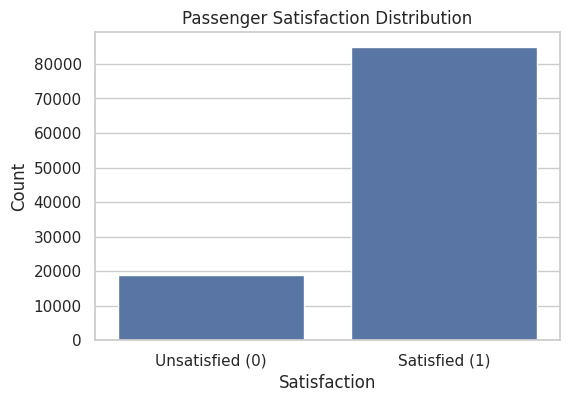

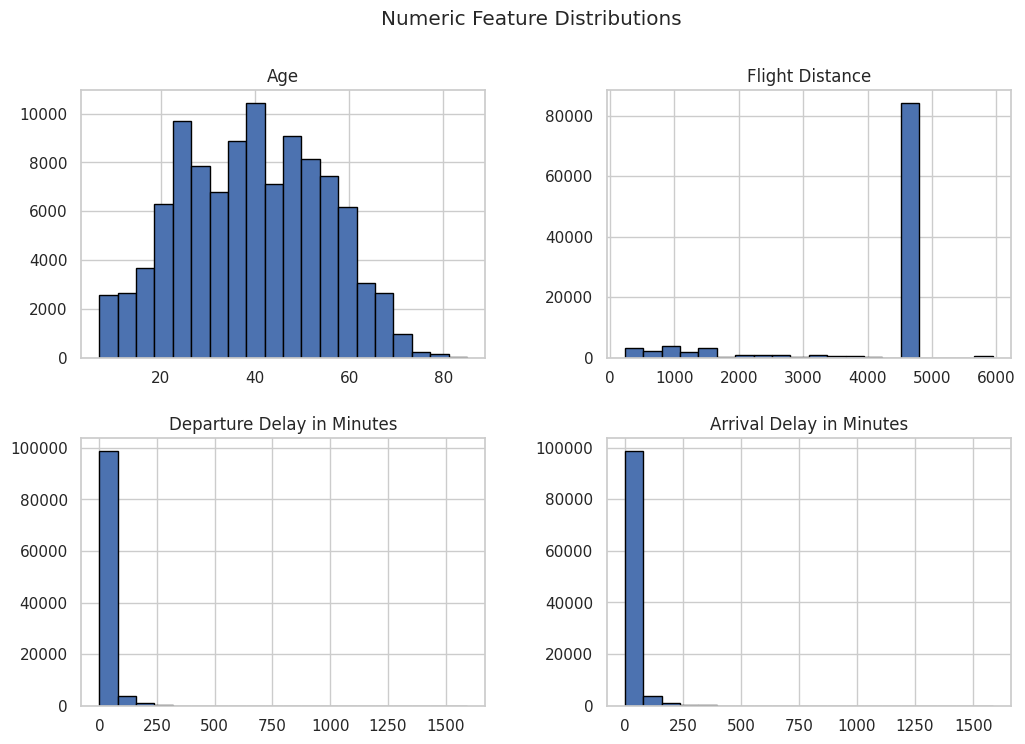

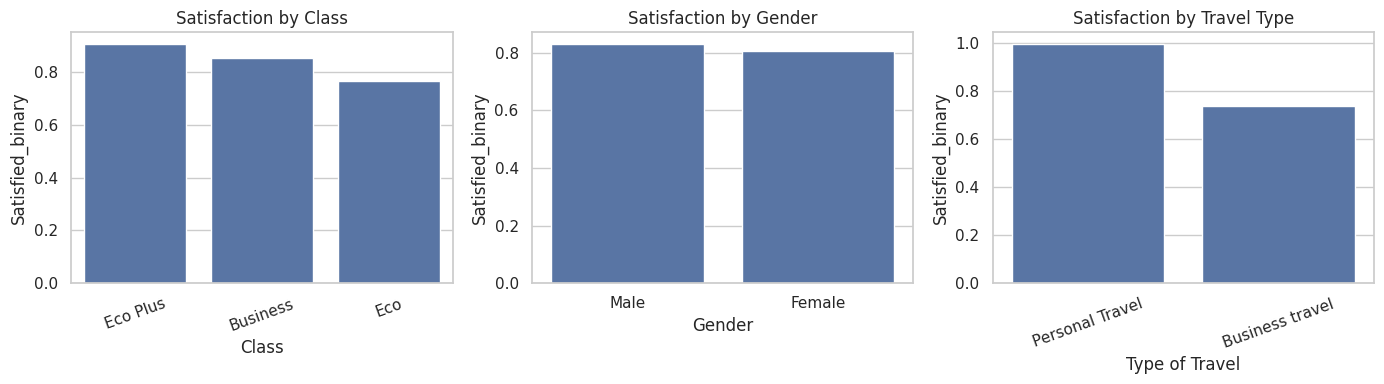

In [ ]:
# PHASE 3: Exploratory Data Analysis (Part 1)

# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Satisfied_binary', data=df)
plt.title('Passenger Satisfaction Distribution')
plt.xticks([0,1], ['Unsatisfied (0)', 'Satisfied (1)'])
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.show()


# Histograms for Key Numeric Features
numeric_features = ['Age', 'Flight Distance',
                    'Departure Delay in Minutes', 'Arrival Delay in Minutes']

df[numeric_features].hist(figsize=(12,8), bins=20, edgecolor='black')
plt.suptitle('Numeric Feature Distributions')
plt.show()


# Satisfaction Rates by Class, Gender, Type of Travel
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.barplot(x='Class', y='Satisfied_binary', data=df, ci=None)
plt.title('Satisfaction by Class')
plt.xticks(rotation=20)

plt.subplot(1,3,2)
sns.barplot(x='Gender', y='Satisfied_binary', data=df, ci=None)
plt.title('Satisfaction by Gender')

plt.subplot(1,3,3)
sns.barplot(x='Type of Travel', y='Satisfied_binary', data=df, ci=None)
plt.title('Satisfaction by Travel Type')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


Correlation with Satisfaction:
Satisfied_binary                     1.000000
Inflight wifi service                0.309855
Age                                  0.281640
Departure/Arrival time convenient    0.206982
Online boarding                      0.189373
Seat comfort                         0.144701
Inflight entertainment               0.110071
Cleanliness                          0.083750
Food and drink                       0.059589
On-board service                     0.056705
Leg room service                     0.048006
Checkin service                      0.032328
Flight Distance                      0.024036
Ease of Online booking               0.019638
Gate location                       -0.005925
Name: Satisfied_binary, dtype: float64


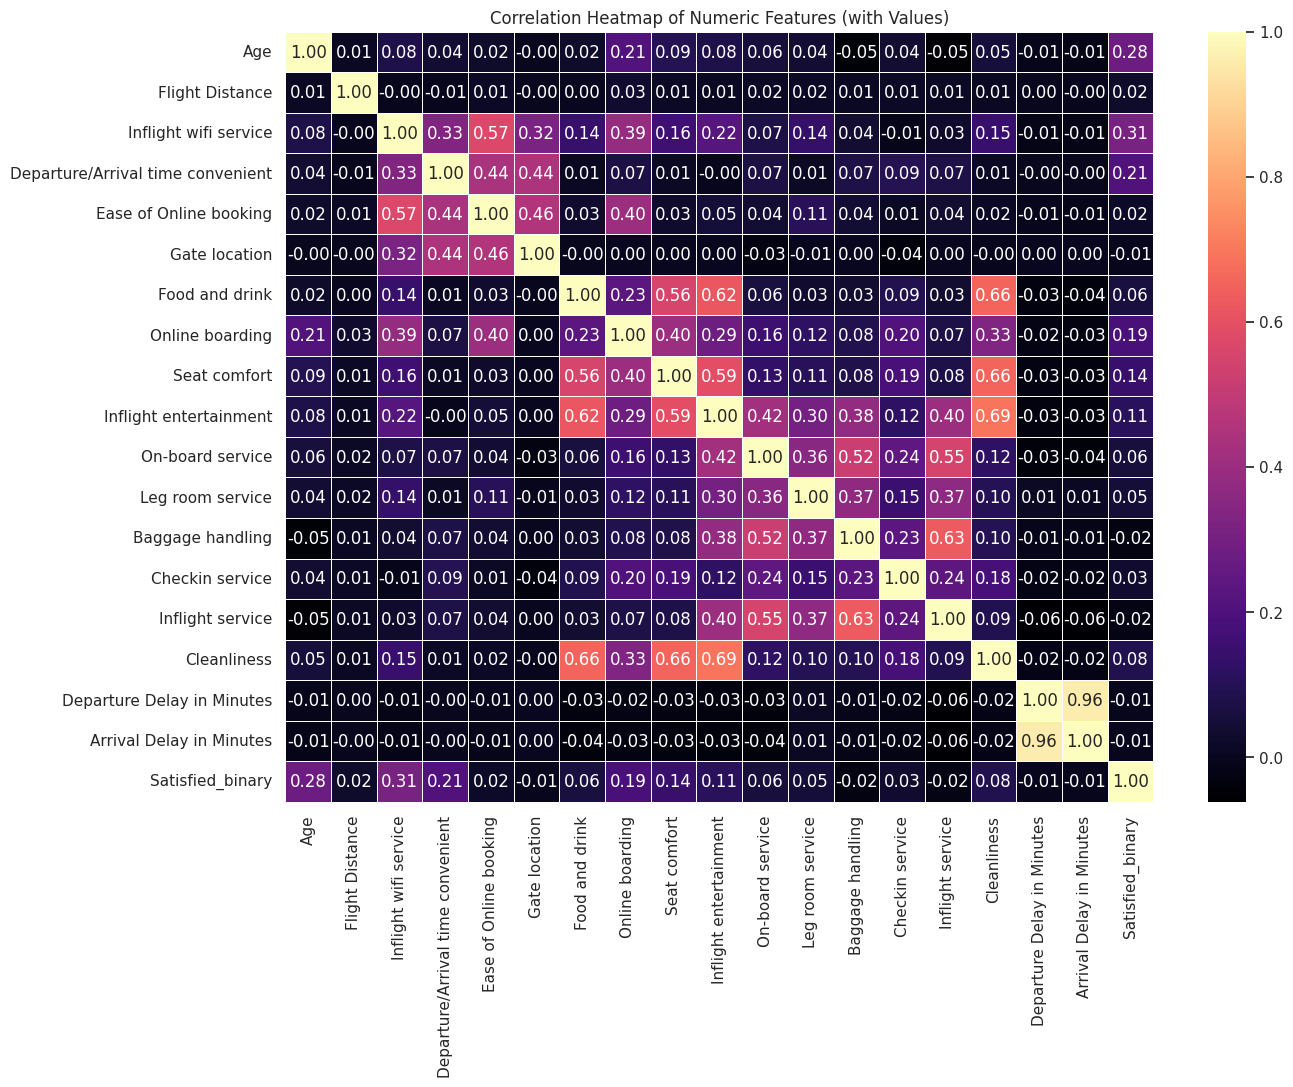

In [ ]:
# PHASE 3: EDA (Part 2)

# Select numeric features including target for correlation
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Focus on features most related to satisfaction
corr_satisfaction = corr_matrix['Satisfied_binary'].sort_values(ascending=False)
print("\nCorrelation with Satisfaction:")
print(corr_satisfaction.head(15))  # top 15 correlations

# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="magma", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features (with Values)")
plt.show()

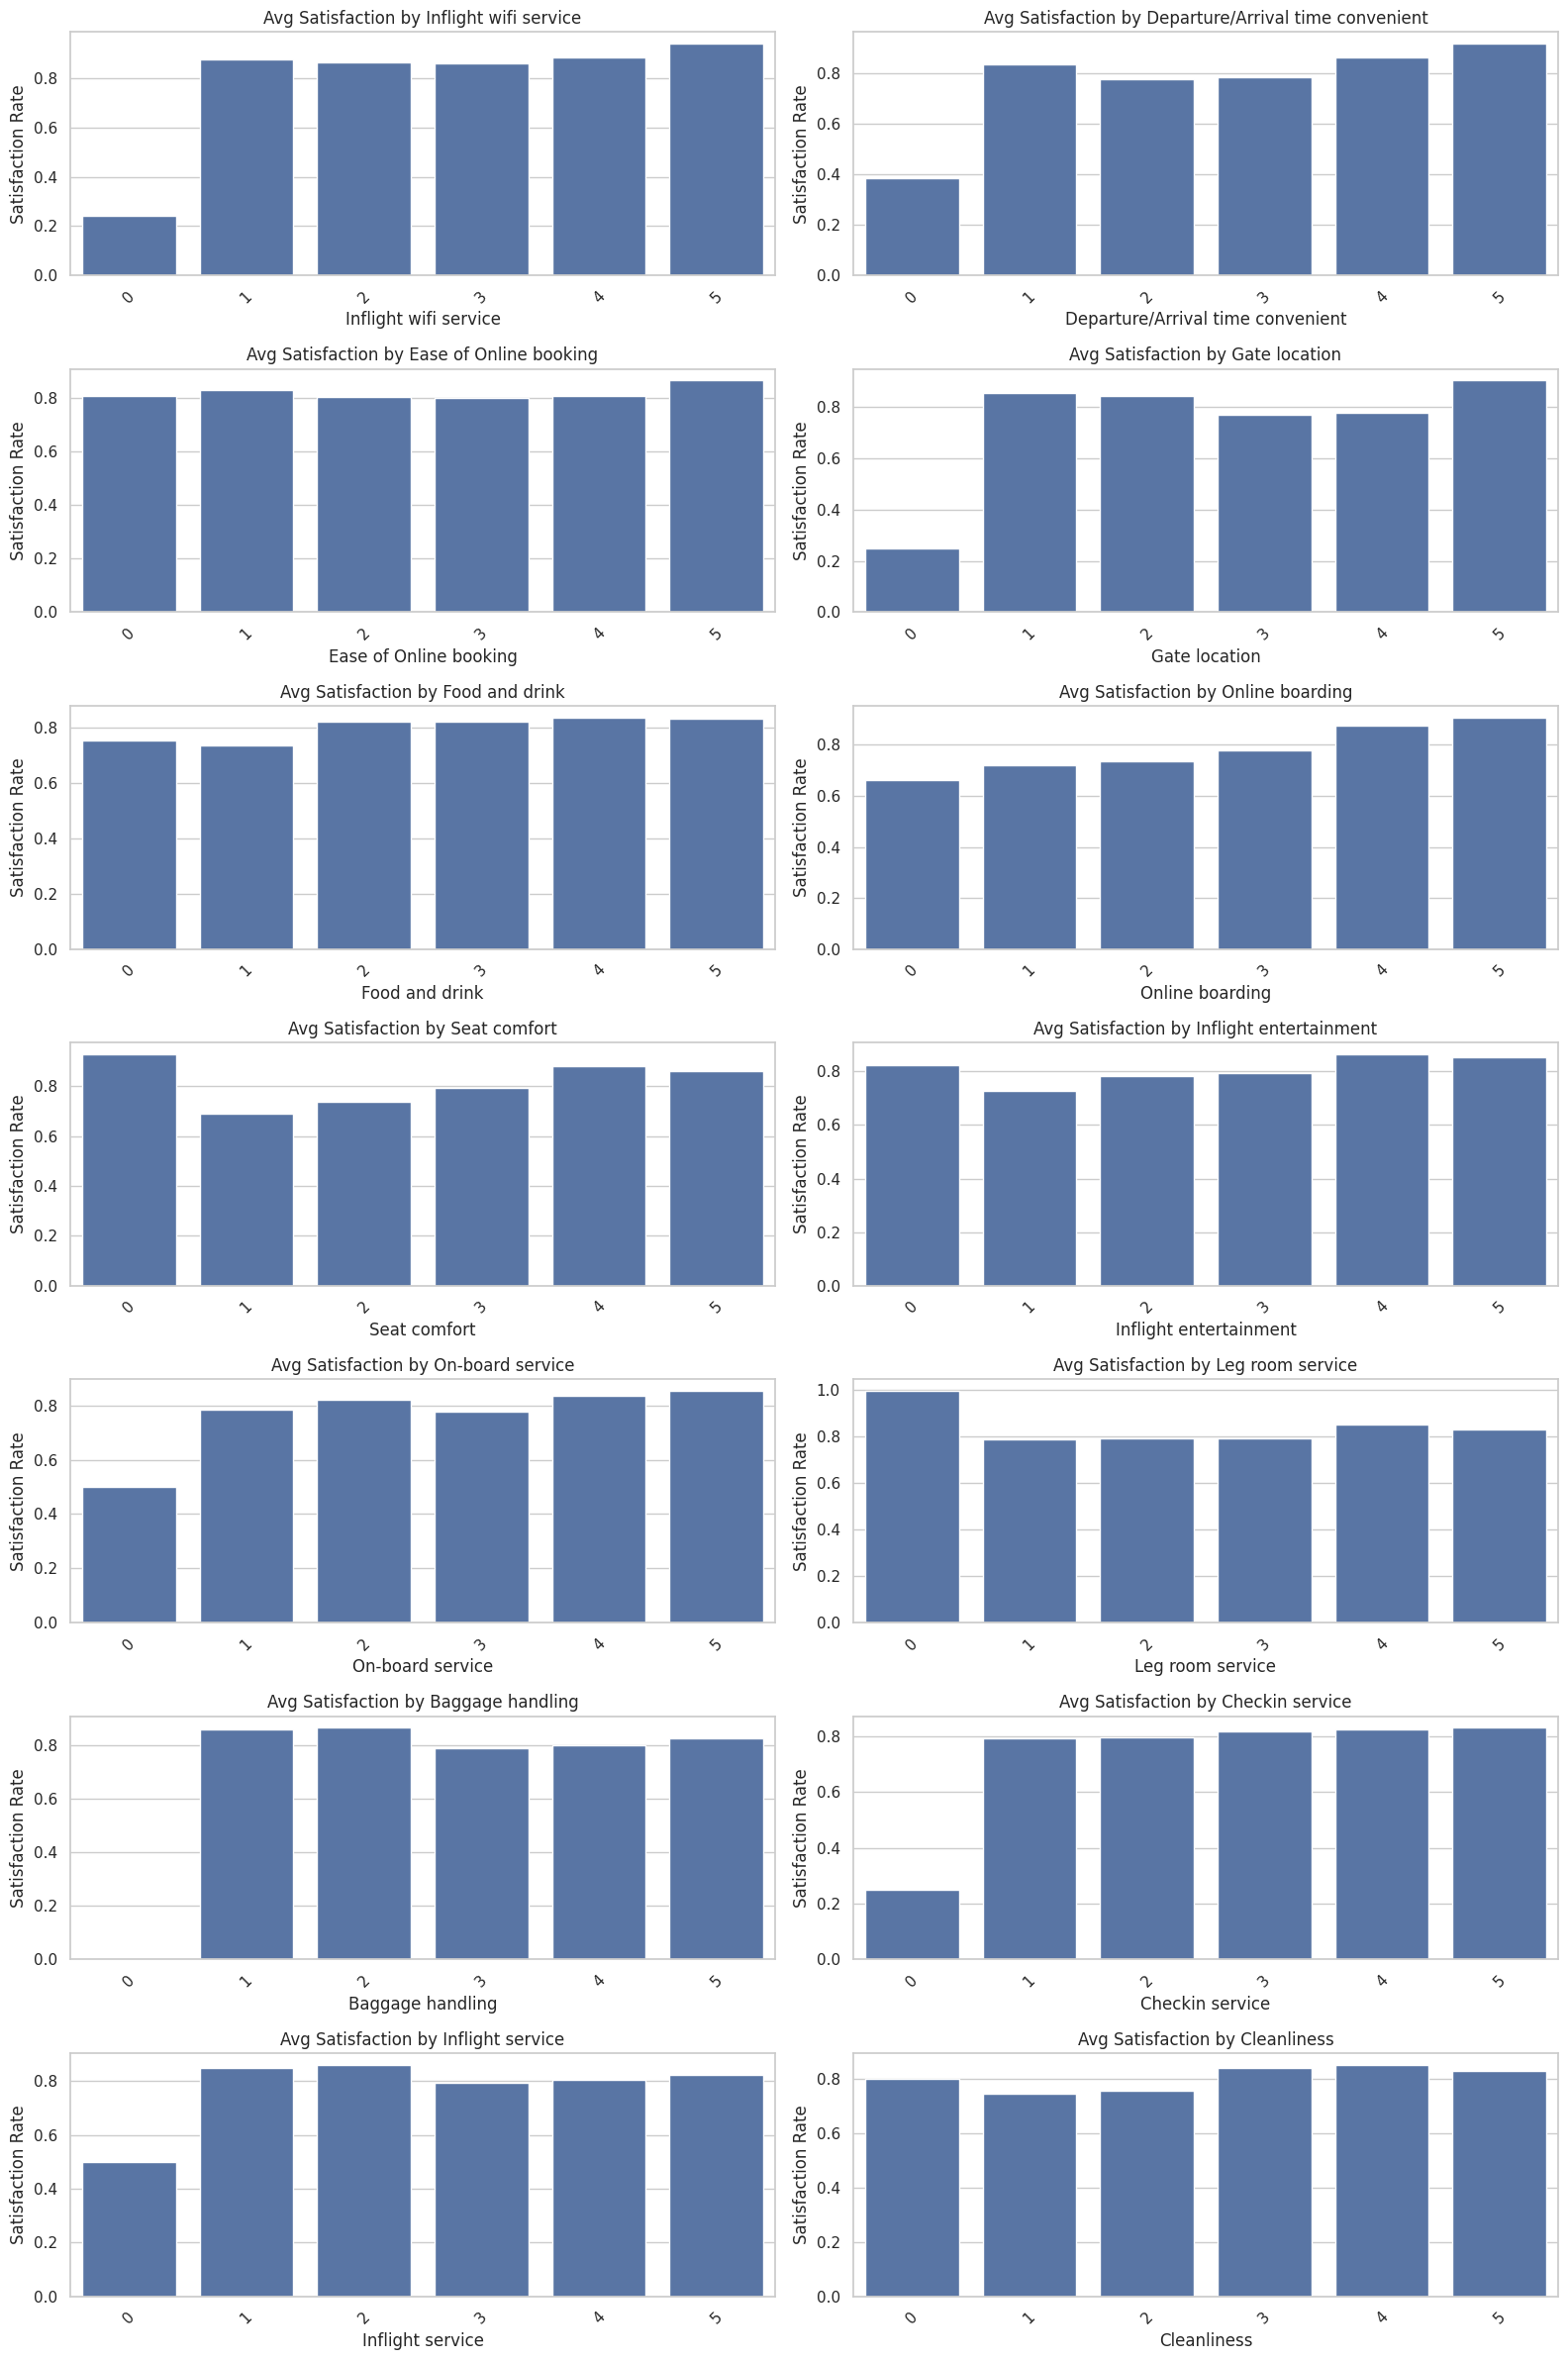

In [ ]:
# Ratings vs Satisfaction (Bar Charts)

rating_features = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

# Mean satisfaction by each rating feature
fig, axes = plt.subplots(7, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(rating_features):
    sns.barplot(x=col, y='Satisfied_binary', data=df, ax=axes[i], ci=None)
    axes[i].set_title(f"Avg Satisfaction by {col}")
    axes[i].set_ylabel("Satisfaction Rate")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# PHASE 4: Train/Test Split + SMOTE

# Features and Target (already defined)
X = df.drop(columns=['Satisfied_binary'])
y = df['Satisfied_binary']

# Identify feature types
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

# Stratified Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

# Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Fit preprocessing ONLY on training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Apply SMOTE after encoding
!pip install imblearn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Categorical Features: ['Gender', 'Age Band', 'Type of Travel', 'Class', 'Destination', 'Continent']
Numerical Features: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Before SMOTE:
Satisfied_binary
1    67936
0    15187
Name: count, dtype: int64

After SMOTE:
Satisfied_binary
1    67936
0    67936
Name: count, dtype: int64


In [ ]:
# PHASE 5: Model Training & Evaluation

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# 1. Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)
rf_pred = rf_model.predict(X_test_preprocessed)
rf_pred_proba = rf_model.predict_proba(X_test_preprocessed)[:,1]

In [ ]:
# Install XGBoost if missing
# !pip install xgboost
from xgboost import XGBClassifier

# 2. XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test_preprocessed)
xgb_pred_proba = xgb_model.predict_proba(X_test_preprocessed)[:,1]

In [ ]:
# =========================================
# Evaluation Metrics Function
# =========================================
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"\n Performance Metrics: {model_name}")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1 Score:", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_proba), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [ ]:
# Display Results for Both Models
evaluate_model(y_test, rf_pred, rf_pred_proba, "Random Forest")


 Performance Metrics: Random Forest
Accuracy: 0.9852
Precision: 0.9907
Recall: 0.9912
F1 Score: 0.991
ROC-AUC: 0.9958

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3797
           1       0.99      0.99      0.99     16984

    accuracy                           0.99     20781
   macro avg       0.98      0.97      0.98     20781
weighted avg       0.99      0.99      0.99     20781



In [ ]:
evaluate_model(y_test, xgb_pred, xgb_pred_proba, "XGBoost")


 Performance Metrics: XGBoost
Accuracy: 0.9925
Precision: 0.994
Recall: 0.9968
F1 Score: 0.9954
ROC-AUC: 0.9982

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3797
           1       0.99      1.00      1.00     16984

    accuracy                           0.99     20781
   macro avg       0.99      0.98      0.99     20781
weighted avg       0.99      0.99      0.99     20781



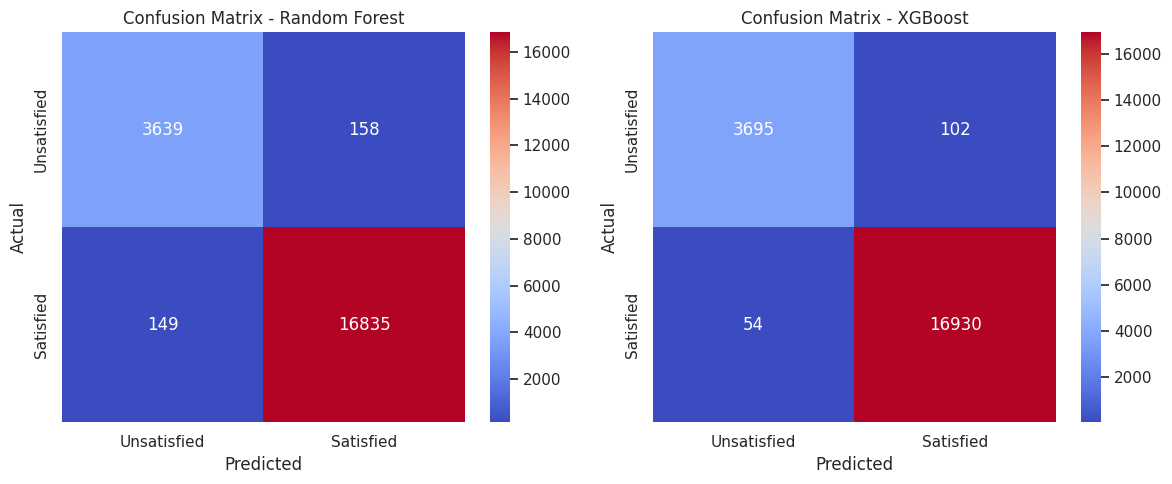

In [ ]:
# CONFUSION MATRICES + FEATURE IMPORTANCE + ROC CURVES

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

# List of models for looping
models = {
    "Random Forest": (rf_model, rf_pred, rf_pred_proba),
    "XGBoost": (xgb_model, xgb_pred, xgb_pred_proba)
}

# A) CONFUSION MATRICES
plt.figure(figsize=(12,5))
for i, (name, (model, pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    plt.subplot(1, 2, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm",
                xticklabels=['Unsatisfied', 'Satisfied'],
                yticklabels=['Unsatisfied', 'Satisfied'])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

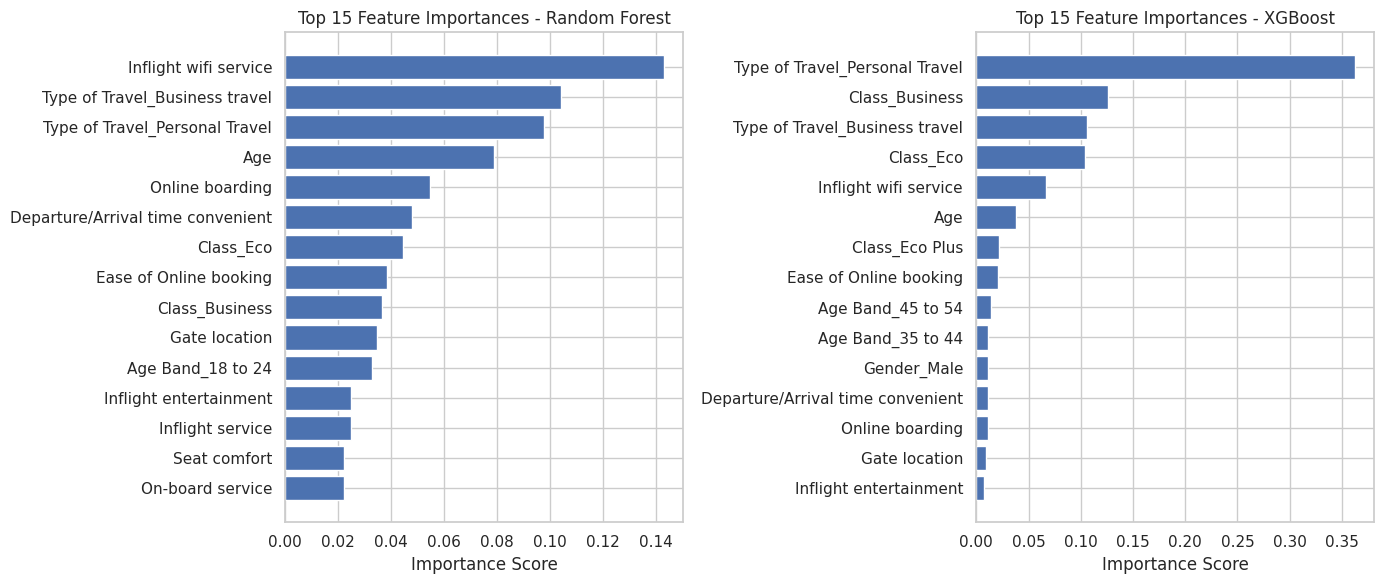

In [ ]:
# B & C) FEATURE IMPORTANCE (Top 15)

# Extract feature names from OneHotEncoder
ohe = preprocessor.named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)
all_features = np.concatenate([numerical_features, encoded_cat_features])

plt.figure(figsize=(14,6))

# Random Forest Top 15
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[-15:]
plt.subplot(1,2,1)
plt.barh(all_features[indices_rf], importances_rf[indices_rf])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")

# XGBoost Top 15
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[-15:]
plt.subplot(1,2,2)
plt.barh(all_features[indices_xgb], importances_xgb[indices_xgb])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

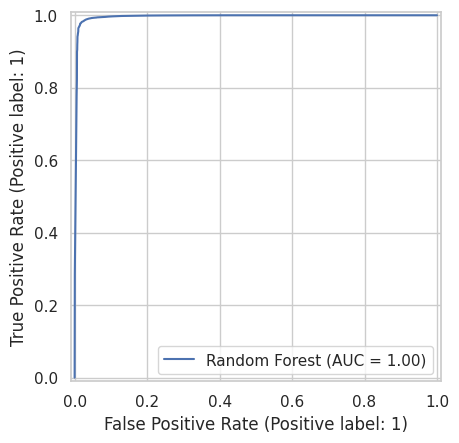

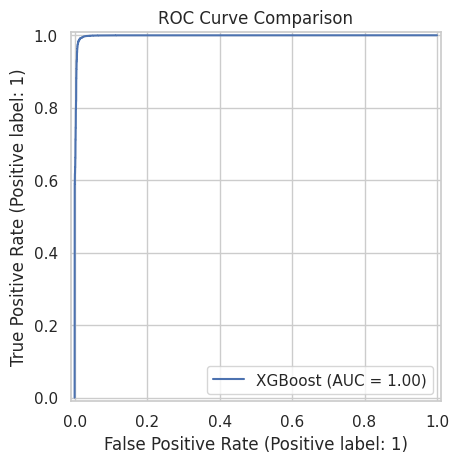

In [ ]:
# D) ROC CURVES
plt.figure(figsize=(10,6))
for name, (model, _, proba) in models.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name)

plt.title("ROC Curve Comparison")
plt.show()

In [ ]:
# SUMMARY METRICS TABLE FOR BOTH MODELS

# Dictionary to store all metrics
metrics_summary = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": [],
    "ROC-AUC": []
}

# Helper function to append metrics
def collect_metrics(name, y_true, y_pred, y_proba):
    metrics_summary["Model"].append(name)
    metrics_summary["Accuracy"].append(round(accuracy_score(y_true, y_pred), 4))
    metrics_summary["Precision"].append(round(precision_score(y_true, y_pred), 4))
    metrics_summary["Recall"].append(round(recall_score(y_true, y_pred), 4))
    metrics_summary["F1-Score"].append(round(f1_score(y_true, y_pred), 4))
    metrics_summary["ROC-AUC"].append(round(roc_auc_score(y_true, y_proba), 4))

# Collect for both models
collect_metrics("Random Forest", y_test, rf_pred, rf_pred_proba)
collect_metrics("XGBoost", y_test, xgb_pred, xgb_pred_proba)

# Create DataFrame summary
metrics_df = pd.DataFrame(metrics_summary)
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9852,0.9907,0.9912,0.9910,0.9958
1,XGBoost,0.9925,0.9940,0.9968,0.9954,0.9982
